## EXPLORATORY DATA ANALYSIS ON FOOD ORDERS - USING PYTHON

In [ ]:
import pandas as pd
import seaborn as sns

# Data preparation

- involves loading, data inspection , missing value analysis and handling, e.t.c

In [ ]:
df = pd.read_csv("food_orders.csv") # loads the csv file to pandas dataframe.

In [ ]:
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Rating,Review,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,4.0,NaN,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                            21321 non-null  object 


In [ ]:
# split date & time column
df[["~order time", "~order date"]] = df["Order Placed At"].str.split(", ", expand=True)


In [ ]:
# glimpse of data

df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID,~order time,~order date
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,11:38 PM,September 10 2024
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,11:34 PM,September 10 2024
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,03:52 PM,September 10 2024
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,03:45 PM,September 10 2024
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,03:04 PM,September 10 2024


In [ ]:
numericDf = df.select_dtypes(include= "number")
non_numericDf = df.select_dtypes(include= "object")

In [ ]:

# summary statistics -- numeric fields
numericDf.describe().iloc[:, 2:]

,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),~order time
count,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,21321.000000,2491.000000,133.000000,3.0,21026.000000,21153.000000,21321
mean,750.076838,32.564592,65.091816,31.795058,0.099128,3.039324,682.616113,4.356885,356.409549,0.0,17.332960,4.825070,0 days 07:25:05.991276206
std,498.759428,22.235898,85.401604,131.487091,3.264261,17.070780,465.313977,1.181472,328.128240,0.0,6.283388,4.982591,0 days 03:23:59.982206763
min,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,52.500000,1.000000,83.580000,0.0,0.000000,0.100000,0 days 01:00:00
25%,459.000000,18.450000,0.000000,0.000000,0.000000,0.000000,387.450000,4.000000,191.950000,0.0,13.380000,1.000000,0 days 04:40:00
50%,629.000000,28.450000,80.000000,0.000000,0.000000,0.000000,597.450000,5.000000,272.580000,0.0,16.330000,3.100000,0 days 07:58:00
75%,899.000000,39.950000,100.000000,0.000000,0.000000,0.000000,837.900000,5.000000,397.840000,0.0,20.050000,7.400000,0 days 10:01:00
max,16080.000000,603.000000,4020.000000,7787.000000,280.100000,554.800000,12663.000000,5.000000,3236.980000,0.0,90.870000,73.800000,0 days 12:59:00


In [ ]:
non_numericDf.describe().T # summary of non-numeric fields

,count,unique,top,freq
Restaurant name,21321,6,Aura Pizzas,14548
Subzone,21321,8,Greater Kailash 2 (GK2),7380
City,21321,1,Delhi NCR,21321
Order Placed At,21321,19114,"08:37 PM, December 31 2024",5
Order Status,21321,6,Delivered,21131
Delivery,21321,1,Zomato Delivery,21321
Distance,21321,22,2km,3558
Items in order,21321,6123,1 x Bageecha Pizza,877
Instructions,720,631,Order: Please send cutlery,6
Discount construct,15823,527,50% off upto Rs.100,3561


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 31 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  object 
 2   Subzone                                             21321 non-null  object 
 3   City                                                21321 non-null  object 
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  object 
 6   Order Status                                        21321 non-null  object 
 7   Delivery                                            21321 non-null  object 
 8   Distance                                            21321 non-null  object 


In [ ]:
df['~order date'] = pd.to_datetime(df['~order date'])

In [ ]:
df['~order time']=  pd.to_timedelta(df['~order time'] + ":00")

In [ ]:
df.head()

,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Order Status,Delivery,Distance,Items in order,...,Cancellation / Rejection reason,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),Order Ready Marked,Customer complaint tag,Customer ID,~order time,~order date
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",...,NaN,NaN,NaN,18.35,11.6,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...,0 days 11:38:00,2024-09-10
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",...,NaN,NaN,NaN,16.95,3.6,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...,0 days 11:34:00,2024-09-10
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,...,NaN,NaN,NaN,14.05,12.2,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...,0 days 03:52:00,2024-09-10
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",...,NaN,NaN,NaN,19.00,3.3,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...,0 days 03:45:00,2024-09-10
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",...,NaN,NaN,NaN,15.97,1.0,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...,0 days 03:04:00,2024-09-10


<Axes: title={'center': 'Missing Values Plot'}>

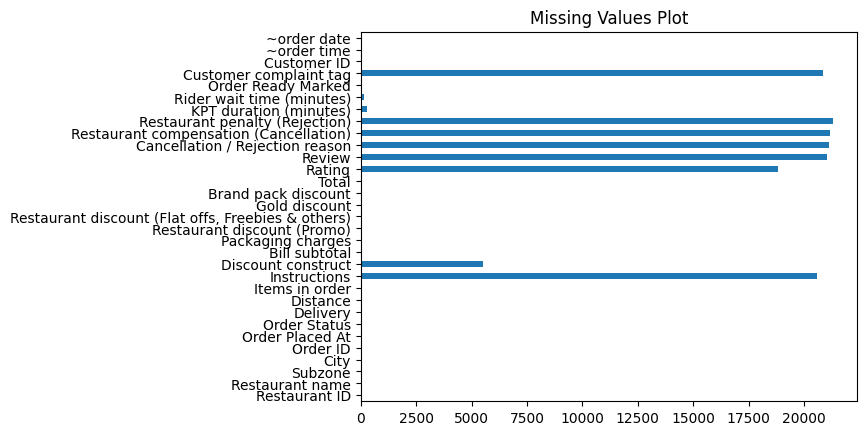

In [ ]:
df.isna().sum().plot(kind="barh", title="Missing Values Plot") # missing value analysis

In [ ]:
df["Distance"].value_counts()

,count
Distance,
2km,3558
1km,3346
3km,3212
4km,2410
5km,2140
6km,2112
7km,1282
9km,767
8km,709


In [ ]:
# save processed data

#df.to_excel("sample_data/food_orders_clean.xlsx", index=False)

# Numeric field plot

- Visualizing numeric fields to discover trends and relationships

<Axes: xlabel='KPT duration (minutes)', ylabel='Rider wait time (minutes)'>

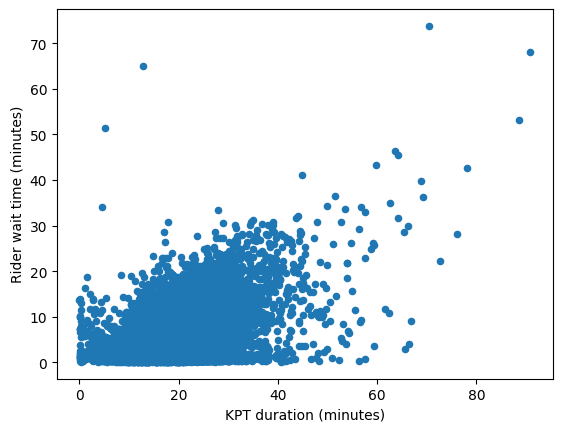

In [ ]:
df[['KPT duration (minutes)',	'Rider wait time (minutes)']].\
plot(kind="scatter", x='KPT duration (minutes)'	,y= 'Rider wait time (minutes)')

In [ ]:
numericDf.head()

,Restaurant ID,Order ID,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),~order time
0,20320607,6168884918,715.0,31.75,80.0,0.0,0.0,0.0,666.75,NaN,NaN,NaN,18.35,11.6,0 days 11:38:00
1,20320607,6170707559,1179.0,50.20,175.0,0.0,0.0,0.0,1054.20,NaN,NaN,NaN,16.95,3.6,0 days 11:34:00
2,20320607,6169375019,310.0,11.50,80.0,0.0,0.0,0.0,241.50,NaN,NaN,NaN,14.05,12.2,0 days 03:52:00
3,20320607,6151677434,620.0,27.00,80.0,0.0,0.0,0.0,567.00,4.0,NaN,NaN,19.00,3.3,0 days 03:45:00
4,20320607,6167540897,584.0,25.20,80.0,0.0,0.0,0.0,529.20,NaN,NaN,NaN,15.97,1.0,0 days 03:04:00


In [ ]:
numericDf.isna().sum()



,0
Restaurant ID,0
Order ID,0
Bill subtotal,0
Packaging charges,0
Restaurant discount (Promo),0
"Restaurant discount (Flat offs, Freebies & others)",0
Gold discount,0
Brand pack discount,0
Total,0
Rating,18830


<Axes: xlabel='KPT duration (minutes)', ylabel='Rider wait time (minutes)'>

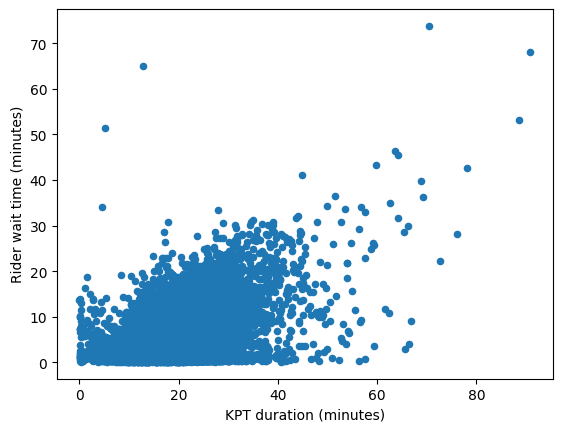

In [ ]:
df[['Restaurant discount (Promo)', 'Total']].\
plot(kind="scatter", x='KPT duration (minutes)'	,y= 'Rider wait time (minutes)')

<Axes: xlabel='Restaurant discount (Promo)', ylabel='Total'>

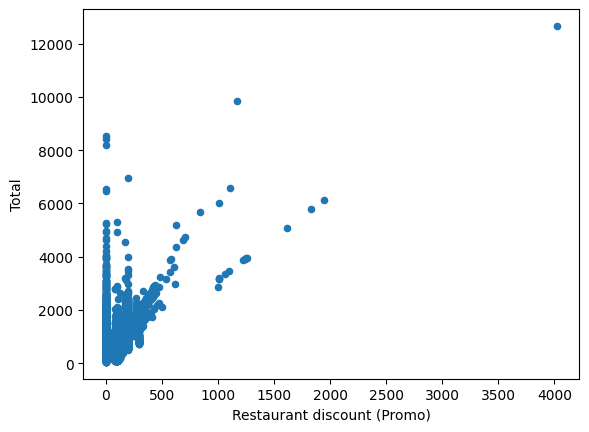

In [ ]:
df[['Restaurant discount (Promo)', 'Total']].\
plot(kind="scatter", x='Restaurant discount (Promo)'	,y= 'Total')

# Categorical fields

In [ ]:
non_numericDf.head()

,Restaurant name,Subzone,City,Order Placed At,Order Status,Delivery,Distance,Items in order,Instructions,Discount construct,Review,Cancellation / Rejection reason,Order Ready Marked,Customer complaint tag,Customer ID
0,Swaad,Sector 4,Delhi NCR,"11:38 PM, September 10 2024",Delivered,Zomato Delivery,3km,"1 x Grilled Chicken Jamaican Tender, 1 x Grill...",NaN,40% off upto Rs.80,NaN,NaN,Correctly,NaN,5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...
1,Swaad,Sector 4,Delhi NCR,"11:34 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",NaN,Flat Rs.175 off,NaN,NaN,Correctly,NaN,0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...
2,Swaad,Sector 4,Delhi NCR,"03:52 PM, September 10 2024",Delivered,Zomato Delivery,<1km,1 x Bone in Peri Peri Grilled Chicken,NaN,40% off upto Rs.80,NaN,NaN,Correctly,NaN,f93362f5ce5382657482d164e368186bcec9c6225fd93d...
3,Swaad,Sector 4,Delhi NCR,"03:45 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",NaN,40% off upto Rs.80,NaN,NaN,Correctly,NaN,1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...
4,Swaad,Sector 4,Delhi NCR,"03:04 PM, September 10 2024",Delivered,Zomato Delivery,2km,"1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",NaN,40% off upto Rs.80,NaN,NaN,Correctly,NaN,d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...


In [ ]:
non_numericDf['Order Status'].value_counts()

,count
Order Status,
Delivered,21131
Rejected,158
Returned,25
Return cancelled,3
Picked up,3
Timed out,1


<Axes: xlabel='Order Status'>

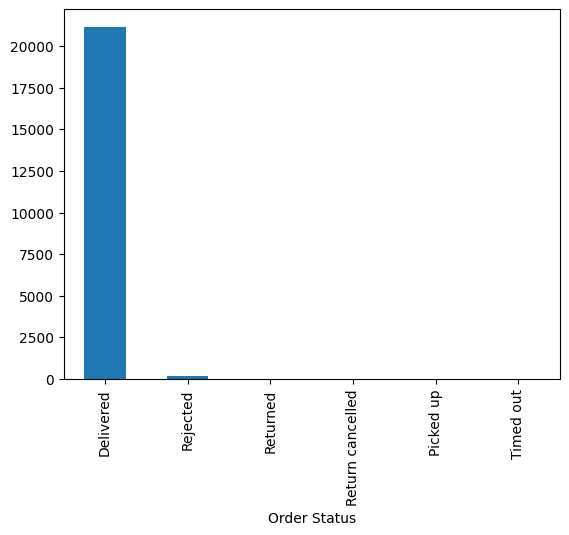

In [ ]:
non_numericDf['Order Status'].value_counts().plot(kind='bar')

In [ ]:
non_numericDf['Restaurant name'].value_counts()

,count
Restaurant name,
Aura Pizzas,14548
Swaad,6332
Dilli Burger Adda,227
Tandoori Junction,154
The Chicken Junction,32
Masala Junction,28


In [ ]:
non_numericDf['Delivery'].value_counts()

,count
Delivery,
Zomato Delivery,21321


In [ ]:
non_numericDf['Order Ready Marked'].value_counts()

,count
Order Ready Marked,
Correctly,19087
Incorrectly,1895
Missed,339


<Axes: ylabel='count'>

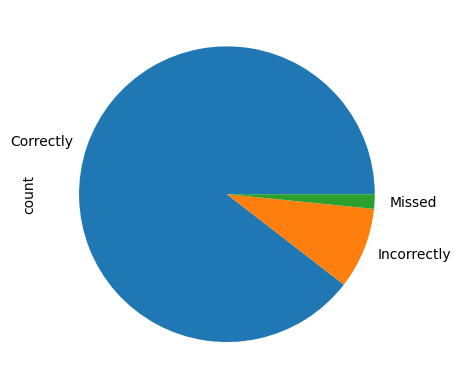

In [ ]:
non_numericDf['Order Ready Marked'].value_counts().plot(kind='pie')

<Axes: xlabel='Distance'>

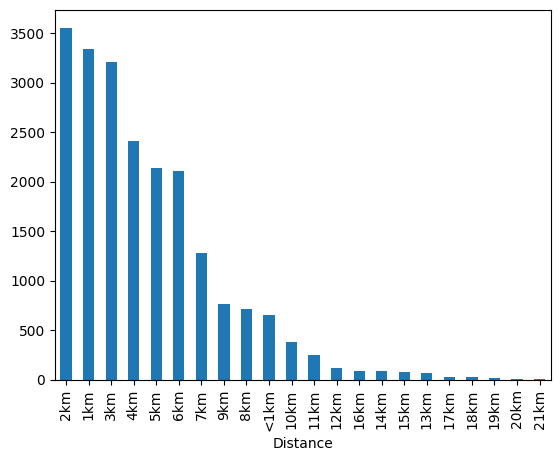

In [ ]:
non_numericDf['Distance'].value_counts().plot(kind='bar')

In [ ]:
non_numericDf['Cancellation / Rejection reason'].value_counts()

,count
Cancellation / Rejection reason,
Cancelled by Customer,89
Cancelled by Zomato,81
Merchant device issue,12
Kitchen is full,3
Items out of stock,1


<Axes: ylabel='count'>

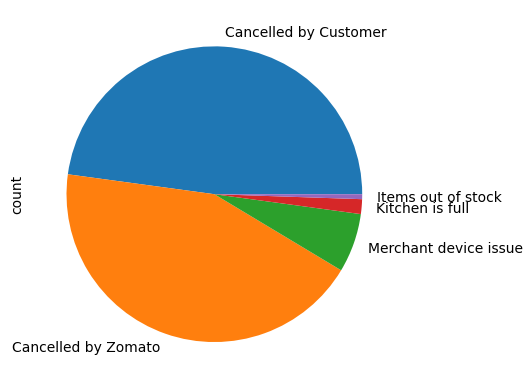

In [ ]:
non_numericDf['Cancellation / Rejection reason'].value_counts().plot(kind='pie')

In [ ]:
non_numericDf['Customer complaint tag'].value_counts()

,count
Customer complaint tag,
Non-refunded complaint,157
Poor taste or quality,120
Poor packaging or spillage,104
Wrong item(s) delivered,48
Item(s) missing or not delivered,40


<Axes: ylabel='count'>

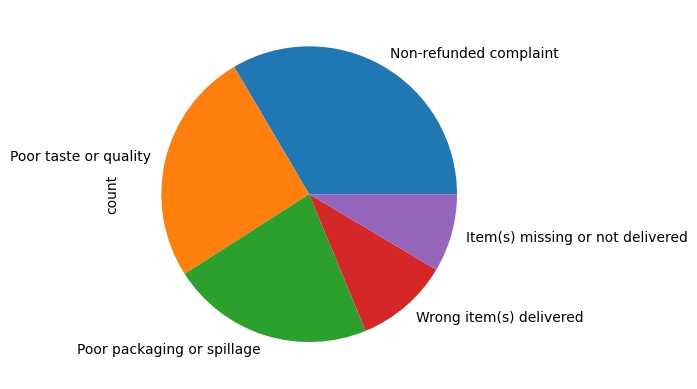

In [ ]:
non_numericDf['Customer complaint tag'].value_counts().plot(kind='pie')

In [ ]:
numericDf.head()

,Restaurant ID,Order ID,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Restaurant compensation (Cancellation),Restaurant penalty (Rejection),KPT duration (minutes),Rider wait time (minutes),~order time
0,20320607,6168884918,715.0,31.75,80.0,0.0,0.0,0.0,666.75,NaN,NaN,NaN,18.35,11.6,0 days 11:38:00
1,20320607,6170707559,1179.0,50.20,175.0,0.0,0.0,0.0,1054.20,NaN,NaN,NaN,16.95,3.6,0 days 11:34:00
2,20320607,6169375019,310.0,11.50,80.0,0.0,0.0,0.0,241.50,NaN,NaN,NaN,14.05,12.2,0 days 03:52:00
3,20320607,6151677434,620.0,27.00,80.0,0.0,0.0,0.0,567.00,4.0,NaN,NaN,19.00,3.3,0 days 03:45:00
4,20320607,6167540897,584.0,25.20,80.0,0.0,0.0,0.0,529.20,NaN,NaN,NaN,15.97,1.0,0 days 03:04:00


In [ ]:
num_df = numericDf[['Bill subtotal', 'Packaging charges',
       'Restaurant discount (Promo)',
       'Restaurant discount (Flat offs, Freebies & others)', 'Gold discount',
       'Brand pack discount', 'Total', 'Rating',
       'Restaurant compensation (Cancellation)',
       'Restaurant penalty (Rejection)']]

In [ ]:
num_df.head()

,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Restaurant compensation (Cancellation),Restaurant penalty (Rejection)
0,715.0,31.75,80.0,0.0,0.0,0.0,666.75,NaN,NaN,NaN
1,1179.0,50.20,175.0,0.0,0.0,0.0,1054.20,NaN,NaN,NaN
2,310.0,11.50,80.0,0.0,0.0,0.0,241.50,NaN,NaN,NaN
3,620.0,27.00,80.0,0.0,0.0,0.0,567.00,4.0,NaN,NaN
4,584.0,25.20,80.0,0.0,0.0,0.0,529.20,NaN,NaN,NaN


# Correlation

- Correlations and heatmap visualization

In [ ]:
num_df.corr()

,Bill subtotal,Packaging charges,Restaurant discount (Promo),"Restaurant discount (Flat offs, Freebies & others)",Gold discount,Brand pack discount,Total,Rating,Restaurant compensation (Cancellation),Restaurant penalty (Rejection)
Bill subtotal,1.000000,0.957385,0.482291,0.230624,0.026750,0.134164,0.958831,0.059984,0.939862,NaN
Packaging charges,0.957385,1.000000,0.393666,-0.004306,0.020060,0.101002,0.999105,0.061174,0.952711,NaN
Restaurant discount (Promo),0.482291,0.393666,1.000000,-0.167665,0.016306,0.086197,0.396335,-0.012751,0.684317,NaN
"Restaurant discount (Flat offs, Freebies & others)",0.230624,-0.004306,-0.167665,1.000000,-0.007344,-0.021145,-0.003982,0.036243,-0.084925,NaN
Gold discount,0.026750,0.020060,0.016306,-0.007344,1.000000,0.040616,0.020208,-0.041763,NaN,NaN
Brand pack discount,0.134164,0.101002,0.086197,-0.021145,0.040616,1.000000,0.101818,-0.041686,0.095419,NaN
Total,0.958831,0.999105,0.396335,-0.003982,0.020208,0.101818,1.000000,0.059611,0.953073,NaN
Rating,0.059984,0.061174,-0.012751,0.036243,-0.041763,-0.041686,0.059611,1.000000,NaN,NaN
Restaurant compensation (Cancellation),0.939862,0.952711,0.684317,-0.084925,NaN,0.095419,0.953073,NaN,1.000000,NaN
Restaurant penalty (Rejection),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

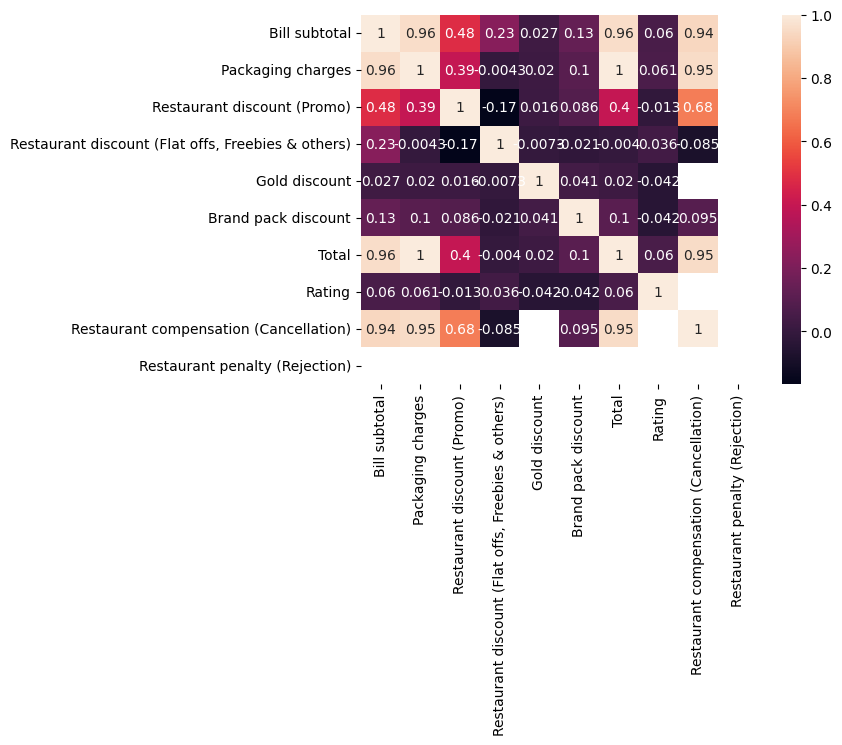

In [ ]:
sns.heatmap(num_df.corr(), annot=True)

Next,

Load the clean data to Tableau for further data analysis and visualization.